In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from scipy.special import expit
import pandas as pd
import sys
from sklearn.metrics import accuracy_score
import struct
# Load the data
data = pd.read_csv('Leases_WithDates_FixedNA.csv')

In [43]:
Month_Fixed_m = {
    '1/1/2018': 1,
    '2/1/2018': 2,
    '3/1/2018': 3,
    '4/1/2018': 4,
    '5/1/2018': 5,
    '6/1/2018': 6,
    '7/1/2018': 7,
    '8/1/2018': 8,
    '9/1/2018': 9,
    '10/1/2018': 10,
    '11/1/2018': 11,
    '12/1/2018': 12,
    '1/1/2019': 13,
    '2/1/2019': 14,
    '3/1/2019': 15,
    '4/1/2019': 16,
    '5/1/2019': 17,
    '6/1/2019': 18,
    '7/1/2019': 19,
    '8/1/2019': 20,
    '9/1/2019': 21,
    '10/1/2019': 22,
    '11/1/2019': 23,
    '12/1/2019': 24,
    '1/1/2020': 25,
    '2/1/2020': 26,
    '3/1/2020': 27,
    '4/1/2020': 28,
    '5/1/2020': 29,
    '6/1/2020': 30,
    '7/1/2020': 31,
    '8/1/2020': 32,
    '9/1/2020': 33,
    '10/1/2020': 34,
    '11/1/2020': 35,
    '12/1/2020': 36,
    '1/1/2021': 37,
    '2/1/2021': 38,
    '3/1/2021': 39,
    '4/1/2021': 40,
    '5/1/2021': 41,
    '6/1/2021': 42,
    '7/1/2021': 43,
    '8/1/2021': 44,
    '9/1/2021': 45,
    '10/1/2021': 46,
    '11/1/2021': 47,
    '12/1/2021': 48,
    '1/1/2022': 49,
    '2/1/2022': 50,
    '3/1/2022': 51,
    '4/1/2022': 52,
    '5/1/2022': 53,
    '6/1/2022': 54,
    '7/1/2022': 55,
    '8/1/2022': 56,
    '9/1/2022': 57,
    '10/1/2022': 58,
    '11/1/2022': 59,
    '12/1/2022': 60,
    '1/1/2023': 61,
    '2/1/2023': 62,
    '3/1/2023': 63,
    '4/1/2023': 64,
    '5/1/2023': 65,
    '6/1/2023': 66,
    '7/1/2023': 67,
    '8/1/2023': 68,
    '9/1/2023': 69,
    '10/1/2023': 70,
    '11/1/2023': 71,
    '12/1/2023': 72,
    '1/1/2024': 73,
    '2/1/2024': 74,
    '3/1/2024': 75,
    '4/1/2024': 76,
    '5/1/2024': 77,
    '6/1/2024': 78,
    '7/1/2024': 79,
    '8/1/2024': 80,
    '9/1/2024': 81,
    '10/1/2024': 82,
    '11/1/2024': 83,
    '12/1/2024': 84
}

Quarter_Fixed_m = {
    '3/1/2018': 1,
    '6/1/2018': 2,
    '9/1/2018': 3,
    '12/1/2018': 4,
    '3/1/2019': 5,
    '6/1/2019': 6,
    '9/1/2019': 7,
    '12/1/2019': 8,
    '3/1/2020': 9,
    '6/1/2020': 10,
    '9/1/2020': 11,
    '12/1/2020': 12,
    '3/1/2021': 13,
    '6/1/2021': 14,
    '9/1/2021': 15,
    '12/1/2021': 16,
    '3/1/2022': 17,
    '6/1/2022': 18,
    '9/1/2022': 19,
    '12/1/2022': 20,
    '3/1/2023': 21,
    '6/1/2023': 22,
    '9/1/2023': 23,
    '12/1/2023': 24,
    '3/1/2024': 25,
    '6/1/2024': 26,
    '9/1/2024': 27,
    '12/1/2024': 28,
}

CBD_suburban_m = {
    'CBD': 0,
    'Suburban': 1
}

space_type_m = {
    'Relet': 1,
    'New': 2,
    'Sublet': 3,
    'NA': 4
}

transaction_type_m = {
    'Expansion': 1,
    'New': 2,
    'Relocation': 3,
    'Renewal': 4,
    'Restructure': 5,
    'Extension': 6,
    'TBD': 7,
    'Renewal and Expansion': 8,
    'Sale - Leaseback': 9
}



internal_class_m = {
    'A': 1,
    'O': 0
}

market_m = {
    'Atlanta': 1,
    'Austin': 2,
    'Baltimore': 3,
    'Boston': 4,
    'Charlotte': 5,
    'Chicago': 6,   
    'Chicago Suburbs': 7,
    'Dallas/Ft Worth': 8,
    'Denver': 9,
    'Detroit': 10,
    'Houston': 11,
    'Los Angeles': 12,
    'Manhattan': 13,
    'Nashville': 14,
    'Northern New Jersey': 15,
    'Northern Virginia': 16,
    'Orange County': 17,
    'Philadelphia': 18,
    'Phoenix': 19,
    'Raleigh/Durham': 20,
    'Salt Lake City': 21,
    'San Diego': 22,
    'San Francisco': 23,
    'Seattle': 24,
    'South Bay/San Jose': 25,
    'South Florida': 26,
    'Southern Maryland': 27,
    'Tampa': 28,
    'Washington D.C.': 29
}

region_m = {
    'South': 1,
    'Northeast': 2,
    'Midwest/Central': 3,
    'West': 4
}

quarter_m = {
    'Q1': 1,
    'Q2': 2,
    'Q3': 3,
    'Q4': 4
}

state_m = {   
    'AL': 1,
    'AK': 2,
    'AZ': 3,
    'AR': 4,
    'CA': 5,
    'CO': 6,
    'CT': 7,
    'DE': 8,
    'FL': 9,
    'GA': 10,
    'HI': 11,
    'ID': 12,
    'IL': 13,
    'IN': 14,
    'IA': 15,
    'KS': 16,
    'KY': 17,
    'LA': 18,
    'ME': 19,
    'MD': 20,
    'MA': 21,
    'MI': 22,
    'MN': 23,
    'MS': 24,
    'MO': 25,
    'MT': 26,
    'NE': 27,
    'NV': 28,
    'NH': 29,
    'NJ': 30,
    'NM': 31,
    'NY': 32,
    'NC': 33,
    'ND': 34,
    'OH': 35,
    'OK': 36,
    'OR': 37,
    'PA': 38,
    'RI': 39,
    'SC': 40,
    'SD': 41,
    'TN': 42,
    'TX': 43,
    'UT': 44,
    'VT': 45,
    'VA': 46,
    'WA': 47,
    'WV': 48,
    'WI': 49,
    'WY': 50,
    'DC': 51,
    'PR': 52
}

In [44]:
data['Month_Fixed'] = data['Month_Fixed'].map(Month_Fixed_m)
data['Quarter_Fixed'] = data['Quarter_Fixed'].map(Quarter_Fixed_m)
data['CBD_suburban'] = data['CBD_suburban'].map(CBD_suburban_m)
data['space_type'] = data['space_type'].map(space_type_m)
data['transaction_type'] = data['transaction_type'].map(transaction_type_m)
data['internal_class'] = data['internal_class'].map(internal_class_m)
data['market'] = data['market'].map(market_m)
data['region'] = data['region'].map(region_m)
data['quarter'] = data['quarter'].map(quarter_m)
data['state'] = data['state'].map(state_m) 

del data['internal_submarket']
del data['internal_market_cluster']
del data['company_name']
del data['building_name']
del data['address']
del data['city']
data['building_id'] = data['building_id'].apply(hash)
industry_to_group = {
    'Financial Services and Insurance': "Professional Services",
    'Construction, Engineering and Architecture': "Hard Industry",
    'Technology, Advertising, Media, and Information': "Professional Services",
    'Manufacturing (except Pharmaceutical, Retail, and Computer Tech)': "Hard Industry",
    'Associations and Non-profit Organizations (except Education and Non-profit Hospitals)': "Public Service",
    'Transportation': "Consumer",
    'Coworking and Executive Suite Companies': "Professional Services",
    'Business, Professional, and Consulting Services (except Financial and Legal) - Including Accounting': "Professional Services",
    'Education': "Public Service",
    'Legal Services': "Professional Services",
    'Real Estate (except coworking providers)': "Professional Services",
    'Healthcare': "Public Service",
    'Personal Services and Recreation': "Consumer",
    'Government': "Public Service",
    'Retail': "Consumer",
    'Energy & Utilities': "Public Service",
    'Pharmaceuticals': "Hard Industry",
    'Agriculture, Forestry, Fishing, Metal & Mineral Mining': "Hard Industry",
    'NA' : "Unknown"
}

# Map and filter
# Map and filter
# Map and filter
# Handle both string 'NA' and actual NaN values
data["industry_group"] = data["internal_industry"].fillna('NA').map(industry_to_group)
# Define groups
industry_groups = ["Public Service", "Hard Industry", "Consumer", "Professional Services", "Unknown"]

# Create dummy columns
for group in industry_groups:
    data[group] = (data["industry_group"] == group).astype(int)

# Ensure rows with "Unknown" are retained
# Remove rows not included in any industry group
# Rows with "Unknown" will still have a value of 1 in the "Unknown" column
data = data[data[industry_groups].sum(axis=1) >= 1]

# Drop unnecessary columns
del data['internal_industry']
del data['industry_group']

data

,year,quarter,monthsigned,market,building_id,region,state,zip,internal_class,leasedSF,...,sublet_internal_class_rent,sublet_overall_rent,leasing,Quarter_Fixed,Month_Fixed,Public Service,Hard Industry,Consumer,Professional Services,Unknown
0,2018,1,1.0,1,-1338862101449569514,1,10,30328.0,1,24736.0,...,NaN,NaN,1205126,1,1,0,0,0,1,0
1,2018,1,1.0,1,8250479584890227931,1,10,30339.0,1,965.0,...,NaN,NaN,1205126,1,1,0,0,0,0,1
2,2018,1,1.0,1,487698013497343883,1,10,30339.0,1,2215.0,...,NaN,NaN,1205126,1,1,0,0,0,0,1
3,2018,1,1.0,1,-2117068436715553376,1,10,30339.0,0,1925.0,...,NaN,NaN,715742,1,1,0,0,0,0,1
4,2018,1,1.0,1,-9118065470900843185,1,10,30338.0,1,2404.0,...,NaN,NaN,1205126,1,1,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145536,2024,4,12.0,28,3589692580087268055,1,9,33607.0,1,19654.0,...,26.162086,24.797899,770384,28,84,0,1,0,0,0
145537,2024,4,12.0,28,1098268729753559283,1,9,33607.0,1,16224.0,...,26.162086,24.797899,770384,28,84,0,0,0,0,1
145538,2024,4,12.0,28,-5604669898352274524,1,9,33602.0,0,8475.0,...,22.768426,24.797899,328947,28,84,0,0,0,1,0
145539,2024,4,12.0,28,-8303203361794055041,1,9,33602.0,1,2014.0,...,26.162086,24.797899,770384,28,84,0,0,0,1,0


In [45]:
from sklearn.preprocessing import StandardScaler

# Your custom list of columns to standardize
cols_to_standardize = ['leasedSF','RBA','available_space','availability_proportion','internal_class_rent', 'overall_rent',
                       'direct_available_space','direct_availability_proportion','direct_internal_class_rent',
                       'direct_overall_rent','sublet_available_space','sublet_availability_proportion',
                       'sublet_internal_class_rent','sublet_overall_rent','leasing']

scaler = StandardScaler()
data[cols_to_standardize] = scaler.fit_transform(data[cols_to_standardize])

In [46]:
data

,year,quarter,monthsigned,market,building_id,region,state,zip,internal_class,leasedSF,...,sublet_internal_class_rent,sublet_overall_rent,leasing,Quarter_Fixed,Month_Fixed,Public Service,Hard Industry,Consumer,Professional Services,Unknown
0,2018,1,1.0,1,-1338862101449569514,1,10,30328.0,1,0.719368,...,NaN,NaN,-0.112979,1,1,0,0,0,1,0
1,2018,1,1.0,1,8250479584890227931,1,10,30339.0,1,-0.264370,...,NaN,NaN,-0.112979,1,1,0,0,0,0,1
2,2018,1,1.0,1,487698013497343883,1,10,30339.0,1,-0.212640,...,NaN,NaN,-0.112979,1,1,0,0,0,0,1
3,2018,1,1.0,1,-2117068436715553376,1,10,30339.0,0,-0.224641,...,NaN,NaN,-0.510533,1,1,0,0,0,0,1
4,2018,1,1.0,1,-9118065470900843185,1,10,30338.0,1,-0.204818,...,NaN,NaN,-0.112979,1,1,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145536,2024,4,12.0,28,3589692580087268055,1,9,33607.0,1,0.509055,...,-0.469986,-0.746001,-0.466144,28,84,0,1,0,0,0
145537,2024,4,12.0,28,1098268729753559283,1,9,33607.0,1,0.367108,...,-0.469986,-0.746001,-0.466144,28,84,0,0,0,0,1
145538,2024,4,12.0,28,-5604669898352274524,1,9,33602.0,0,0.046424,...,-0.727941,-0.746001,-0.824749,28,84,0,0,0,1,0
145539,2024,4,12.0,28,-8303203361794055041,1,9,33602.0,1,-0.220958,...,-0.469986,-0.746001,-0.466144,28,84,0,0,0,1,0


In [47]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 141890 entries, 0 to 145540
Data columns (total 35 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   year                            141890 non-null  int64  
 1   quarter                         141890 non-null  int64  
 2   monthsigned                     141208 non-null  float64
 3   market                          141890 non-null  int64  
 4   building_id                     141890 non-null  int64  
 5   region                          141890 non-null  int64  
 6   state                           141890 non-null  int64  
 7   zip                             141889 non-null  float64
 8   internal_class                  141890 non-null  int64  
 9   leasedSF                        141890 non-null  float64
 10  transaction_type                141532 non-null  float64
 11  costarID                        141890 non-null  int64  
 12  space_type           

In [48]:
data2 = pd.read_csv('MajorMarketOccupancyData-revised.csv')


unique = data2['market'].unique()
print(unique, " ", len(unique))

data2['quarter'] = data2['quarter'].map(quarter_m)
data2['market'] = data2['market'].map(market_m)
print(data2.describe())


['Washington D.C.' 'Manhattan' 'Chicago' 'Houston' 'Philadelphia'
 'San Francisco' 'Los Angeles' 'Dallas/Ft Worth' 'South Bay/San Jose'
 'Austin']   10
              year     quarter      market  ending_occupancy_proportion  \
count   190.000000  190.000000  190.000000                   190.000000   
mean   2021.894737    2.421053   14.700000                     0.351158   
std       1.376090    1.094275    8.365304                     0.152696   
min    2020.000000    1.000000    2.000000                     0.080000   
25%    2021.000000    1.000000    8.000000                     0.220000   
50%    2022.000000    2.000000   12.500000                     0.355000   
75%    2023.000000    3.000000   23.000000                     0.470000   
max    2024.000000    4.000000   29.000000                     0.660000   

       starting_occupancy_proportion  avg_occupancy_proportion  
count                     190.000000                190.000000  
mean                        0.377895      

In [49]:
data2.head()

,year,quarter,market,ending_occupancy_proportion,starting_occupancy_proportion,avg_occupancy_proportion
0,2020,1,29,0.19,0.98,0.785714
1,2020,1,13,0.08,0.98,0.732857
2,2020,1,6,0.14,0.99,0.788571
3,2020,1,11,0.33,0.99,0.835714
4,2020,1,18,0.20,0.99,0.817143


In [50]:
merged = pd.merge(data, data2, on=['year', 'quarter', 'market'], how='inner')
merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37546 entries, 0 to 37545
Data columns (total 38 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   year                            37546 non-null  int64  
 1   quarter                         37546 non-null  int64  
 2   monthsigned                     37432 non-null  float64
 3   market                          37546 non-null  int64  
 4   building_id                     37546 non-null  int64  
 5   region                          37546 non-null  int64  
 6   state                           37546 non-null  int64  
 7   zip                             37546 non-null  float64
 8   internal_class                  37546 non-null  int64  
 9   leasedSF                        37546 non-null  float64
 10  transaction_type                37457 non-null  float64
 11  costarID                        37546 non-null  int64  
 12  space_type                      

In [51]:
summary = merged.describe()
summary = summary.transpose()
# Drop only the columns you don't need for calculations
columns_to_drop = ['year','quarter', 'monthsigned', 'market', 'building_id', 'region', 'state', 'zip', 
                   'internal_class', 'leasedSF', 'transaction_type', 
                   'costarID', 'space_type', 'CBD_suburban']
summary.drop(columns_to_drop, axis=0, inplace=True)

# Ensure 'summarynont' retains necessary columns
summarynont = summary.copy()

# Transpose back for further processing
summary = summary.transpose()

# Initialize the data description DataFrame
data_des = pd.DataFrame()
data_des['Attributes'] = merged.columns
data_des['Description'] = 'N/A'
data_des['Mean'] = 'N/A'
data_des['Std Deviation'] = 'N/A'
data_des['Range'] = 'N/A'
data_des['Median'] = 'N/A'

data_des['Description']= ['Year of Sale (Dropped in Model for Month,Quarter Fixed)','Quarter of Sale (Dropped in Model)',
                          'Month of Sale (Dropped in Model)','Market (One-Hot Encoded)','Building ID (Dropped in Model)',
                          'Region (Dropped in Model)','State (Dropped in Model)','Zip Code (Dropped in Model)','Quality of Building,'
                          ' Turned into boolean', 'Leased Square Footage (Standardized)',
                          'Transaction Type (One-Hot Encoded)','Costar ID (Dropped in Model)','Space Type (One-Hot Encoded)',
                          'CBD/Suburban (Boolean)', 'Total Leaseable Square Footage (Standardized)', 'Available Square Footage (Standardized)',
                          'Availability Proportion (Standardized)','Internal Class Rent (Standardized)','Overall Rent (Standardized)',
                          'Direct Available Square Footage (Standardized)','Direct Availability Proportion (Standardized)',
                          'Direct Internal Class Rent (Standardized)','Direct Overall Rent (Standardized)',
                          'Sublet Available Square Footage (Standardized)','Sublet Availability Proportion (Standardized)',
                          'Sublet Internal Class Rent (Standardized)','Sublet Overall Rent (Standardized)',
                          'Leasing Rate (Standardized)','Sequential Quarters','Sequential Months','End occupancy', 'Start occupancy', 'Average occupancy','1'
                        ,'3','4','5','6']
# Update the description of the data
for col in merged.columns:
    if col not in columns_to_drop:  # Skip dropped columns
        if col in summarynont.index:  # Check if the column exists in summarynont
            data_des.loc[data_des['Attributes'] == col, 'Mean'] = round(merged[col].mean(), 5)
            data_des.loc[data_des['Attributes'] == col, 'Std Deviation'] = round(merged[col].std(), 5)
            data_des.loc[data_des['Attributes'] == col, 'Range'] = f"{round(summarynont.loc[col, 'min'], 3)}-{round(summarynont.loc[col, 'max'], 3)}"
            data_des.loc[data_des['Attributes'] == col, 'Median'] = round(merged[col].median(), 5)

data_des

,Attributes,Description,Mean,Std Deviation,Range,Median
0,year,"Year of Sale (Dropped in Model for Month,Quart...",N/A,N/A,N/A,N/A
1,quarter,Quarter of Sale (Dropped in Model),N/A,N/A,N/A,N/A
2,monthsigned,Month of Sale (Dropped in Model),N/A,N/A,N/A,N/A
3,market,Market (One-Hot Encoded),N/A,N/A,N/A,N/A
4,building_id,Building ID (Dropped in Model),N/A,N/A,N/A,N/A
5,region,Region (Dropped in Model),N/A,N/A,N/A,N/A
6,state,State (Dropped in Model),N/A,N/A,N/A,N/A
7,zip,Zip Code (Dropped in Model),N/A,N/A,N/A,N/A
8,internal_class,"Quality of Building, Turned into boolean",N/A,N/A,N/A,N/A
9,leasedSF,Leased Square Footage (Standardized),N/A,N/A,N/A,N/A


In [52]:
merged.head()

,year,quarter,monthsigned,market,building_id,region,state,zip,internal_class,leasedSF,...,Quarter_Fixed,Month_Fixed,Public Service,Hard Industry,Consumer,Professional Services,Unknown,ending_occupancy_proportion,starting_occupancy_proportion,avg_occupancy_proportion
0,2020,1,1.0,2,4859169157557507677,1,43,78704.0,0,-0.191989,...,9,25,0,0,0,0,1,0.26,0.98,0.82
1,2020,1,1.0,2,4859169157557507677,1,43,78704.0,0,-0.167738,...,9,25,0,0,0,0,1,0.26,0.98,0.82
2,2020,1,1.0,2,8945006271021153064,1,43,78701.0,1,0.045348,...,9,25,0,0,0,0,1,0.26,0.98,0.82
3,2020,1,1.0,2,-6434765118050113527,1,43,78735.0,1,1.143927,...,9,25,0,0,0,1,0,0.26,0.98,0.82
4,2020,1,1.0,2,-3268048307140920793,1,43,78757.0,0,-0.267515,...,9,25,0,0,0,0,1,0.26,0.98,0.82


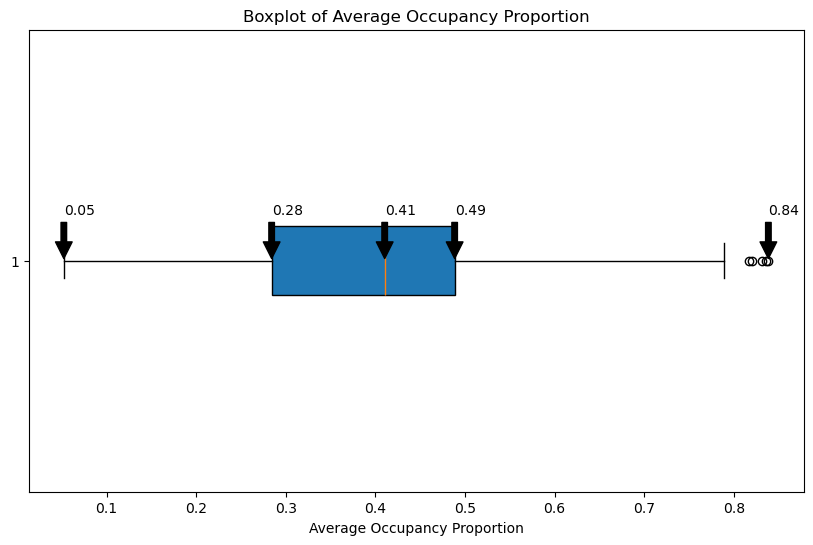

In [53]:
occupancy = data2['avg_occupancy_proportion'].dropna()

plt.figure(figsize=(10, 6))
box = plt.boxplot(occupancy, vert=False, patch_artist=True)

# Extracting the statistics
stats = {
    'min': occupancy.min(),
    'Q1': occupancy.quantile(0.25),
    'median': occupancy.median(),
    'Q3': occupancy.quantile(0.75),
    'max': occupancy.max()
}

# Adding annotations
for key, value in stats.items():
    plt.annotate(f'{value:.2f}', xy=(value, 1), xytext=(value, 1.1),
                 arrowprops=dict(facecolor='black', shrink=0.05))

plt.title('Boxplot of Average Occupancy Proportion')
plt.xlabel('Average Occupancy Proportion')
plt.show()

In [54]:
bins = [data2['avg_occupancy_proportion'].min(), data2['avg_occupancy_proportion'].quantile(0.125), data2['avg_occupancy_proportion'].quantile(0.25), data2['avg_occupancy_proportion'].quantile(0.375), data2['avg_occupancy_proportion'].median(), data2['avg_occupancy_proportion'].quantile(0.625), data2['avg_occupancy_proportion'].quantile(0.75), data2['avg_occupancy_proportion'].quantile(0.875), data2['avg_occupancy_proportion'].max()]
labels = [1, 2, 3, 4, 5, 6, 7, 8]

# Create a new column with the binned merged
merged['avg_occupancy_proportionClass'] = pd.cut(merged['avg_occupancy_proportion'], bins=bins, labels=labels, include_lowest=True)

# Print the relevant columns for visualization
print(merged[['avg_occupancy_proportion', 'avg_occupancy_proportionClass']])

       avg_occupancy_proportion avg_occupancy_proportionClass
0                      0.820000                             8
1                      0.820000                             8
2                      0.820000                             8
3                      0.820000                             8
4                      0.820000                             8
...                         ...                           ...
37541                  0.402308                             4
37542                  0.402308                             4
37543                  0.402308                             4
37544                  0.392308                             4
37545                  0.392308                             4

[37546 rows x 2 columns]


In [55]:
merged.head()

,year,quarter,monthsigned,market,building_id,region,state,zip,internal_class,leasedSF,...,Month_Fixed,Public Service,Hard Industry,Consumer,Professional Services,Unknown,ending_occupancy_proportion,starting_occupancy_proportion,avg_occupancy_proportion,avg_occupancy_proportionClass
0,2020,1,1.0,2,4859169157557507677,1,43,78704.0,0,-0.191989,...,25,0,0,0,0,1,0.26,0.98,0.82,8
1,2020,1,1.0,2,4859169157557507677,1,43,78704.0,0,-0.167738,...,25,0,0,0,0,1,0.26,0.98,0.82,8
2,2020,1,1.0,2,8945006271021153064,1,43,78701.0,1,0.045348,...,25,0,0,0,0,1,0.26,0.98,0.82,8
3,2020,1,1.0,2,-6434765118050113527,1,43,78735.0,1,1.143927,...,25,0,0,0,1,0,0.26,0.98,0.82,8
4,2020,1,1.0,2,-3268048307140920793,1,43,78757.0,0,-0.267515,...,25,0,0,0,0,1,0.26,0.98,0.82,8


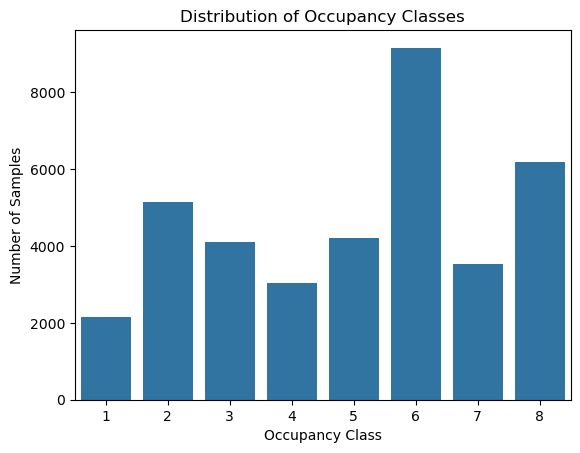

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='avg_occupancy_proportionClass', data=merged, order=sorted(merged['avg_occupancy_proportionClass'].unique()))
plt.xlabel('Occupancy Class')
plt.ylabel('Number of Samples')
plt.title('Distribution of Occupancy Classes')
plt.show()

In [59]:
import os
os.environ['KMP_DUPLICATE_LIB_OK']='True'

import numpy as np
from tensorflow.keras.preprocessing import sequence


from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, LSTM, SpatialDropout1D
from tensorflow.keras.preprocessing.text import Tokenizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

merged = merged.dropna(subset=['avg_occupancy_proportionClass'])
merged = merged.dropna()
merged['avg_occupancy_proportionClass'] = merged['avg_occupancy_proportionClass'].astype(int)

from tensorflow.keras.utils import to_categorical

y_train = to_categorical(merged['avg_occupancy_proportionClass'], num_classes=9)

In [60]:
y = merged['avg_occupancy_proportionClass']
y = pd.get_dummies(y)
merged.drop(columns=['avg_occupancy_proportion','year','monthsigned','quarter', 'building_id', 'region', 'state', 'zip' ], inplace=True)
X_train, X_test, y_train, y_test = train_test_split(merged.drop(columns=['avg_occupancy_proportionClass']), y, test_size=0.20, random_state=1)
# First split: separate test set
X_train_val, X_test, y_train_val, y_test = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# Second split: separate validation set from training set
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.2, random_state=42)
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)
print(X_train.shape[0])
X_train

(18764, 30)
(18764, 8)
(5864, 30)
(5864, 8)
18764


,market,internal_class,leasedSF,transaction_type,costarID,space_type,CBD_suburban,RBA,available_space,availability_proportion,...,leasing,Quarter_Fixed,Month_Fixed,Public Service,Hard Industry,Consumer,Professional Services,Unknown,ending_occupancy_proportion,starting_occupancy_proportion
35239,12,1,-0.079715,2.0,108163,3.0,0,1.032976,1.886057,1.022307,...,0.626042,20,59,0,0,0,0,1,0.25,0.45
30904,12,1,-0.235815,2.0,247623,1.0,1,0.994931,1.241502,0.224985,...,0.018893,12,35,0,0,0,0,1,0.20,0.28
12387,12,0,-0.266439,2.0,249850,1.0,0,-0.294611,-0.104260,0.483026,...,-0.554484,14,40,0,0,0,0,1,0.28,0.22
36391,11,1,-0.053270,2.0,234961,2.0,1,0.465782,1.541521,1.746276,...,0.045144,24,70,0,0,0,0,1,0.29,0.60
20833,11,1,0.570138,2.0,235937,1.0,1,0.448051,1.726688,2.113734,...,-0.028173,15,42,0,0,0,0,1,0.48,0.47
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6500,12,0,-0.278441,2.0,248535,1.0,0,-0.284023,-0.001632,0.732941,...,-0.641842,21,61,0,0,0,0,1,0.48,0.32
30696,2,0,-0.284400,2.0,591487,1.0,1,-1.010991,-1.095929,-0.464034,...,-0.884201,12,35,0,0,0,0,1,0.24,0.34
37053,11,1,0.505496,2.0,233974,3.0,1,0.465782,1.541521,1.746276,...,0.045144,24,71,0,0,0,0,1,0.29,0.60
1175,11,0,-0.104214,2.0,238063,1.0,1,-0.173005,0.086001,0.599545,...,-0.372303,9,26,0,0,0,0,1,0.33,0.99


/users/cdcook/.conda/envs/cobaya_2025/lib/python3.9/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1/50
Training Loss: 0.6476, Training Accuracy: 0.7573
Validation Loss: 0.1732, Validation Accuracy: 0.9375
Epoch 2/50
Training Loss: 0.2931, Training Accuracy: 0.8877
Validation Loss: 0.0876, Validation Accuracy: 0.9638
Epoch 3/50
Training Loss: 0.2147, Training Accuracy: 0.9177
Validation Loss: 0.0636, Validation Accuracy: 0.9670
Epoch 4/50
Training Loss: 0.1715, Training Accuracy: 0.9351
Validation Loss: 0.0387, Validation Accuracy: 0.9800
Epoch 5/50
Training Loss: 0.1322, Training Accuracy: 0.9500
Validation Loss: 0.0259, Validation Accuracy: 0.9889
Epoch 6/50
Training Loss: 0.1260, Training Accuracy: 0.9554
Validation Loss: 0.0249, Validation Accuracy: 0.9859
Epoch 7/50
Training Loss: 0.1039, Training Accuracy: 0.9622
Validation Loss: 0.0328, Validation Accuracy: 0.9861
Epoch 8/50
Training Loss: 0.0919, Training Accuracy: 0.9685
Validation Loss: 0.0165, Validation Accuracy: 0.9934
Epoch 9/50
Training Loss: 0.0800, Training Accuracy: 0.9721
Validation Loss: 0.0131, Validation 

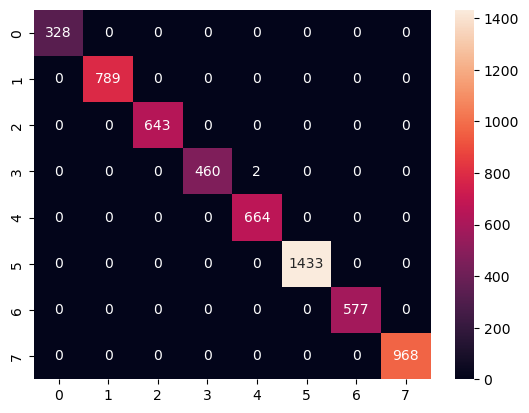


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       328
           1       1.00      1.00      1.00       789
           2       1.00      1.00      1.00       643
           3       1.00      1.00      1.00       462
           4       1.00      1.00      1.00       664
           5       1.00      1.00      1.00      1433
           6       1.00      1.00      1.00       577
           7       1.00      1.00      1.00       968

    accuracy                           1.00      5864
   macro avg       1.00      1.00      1.00      5864
weighted avg       1.00      1.00      1.00      5864



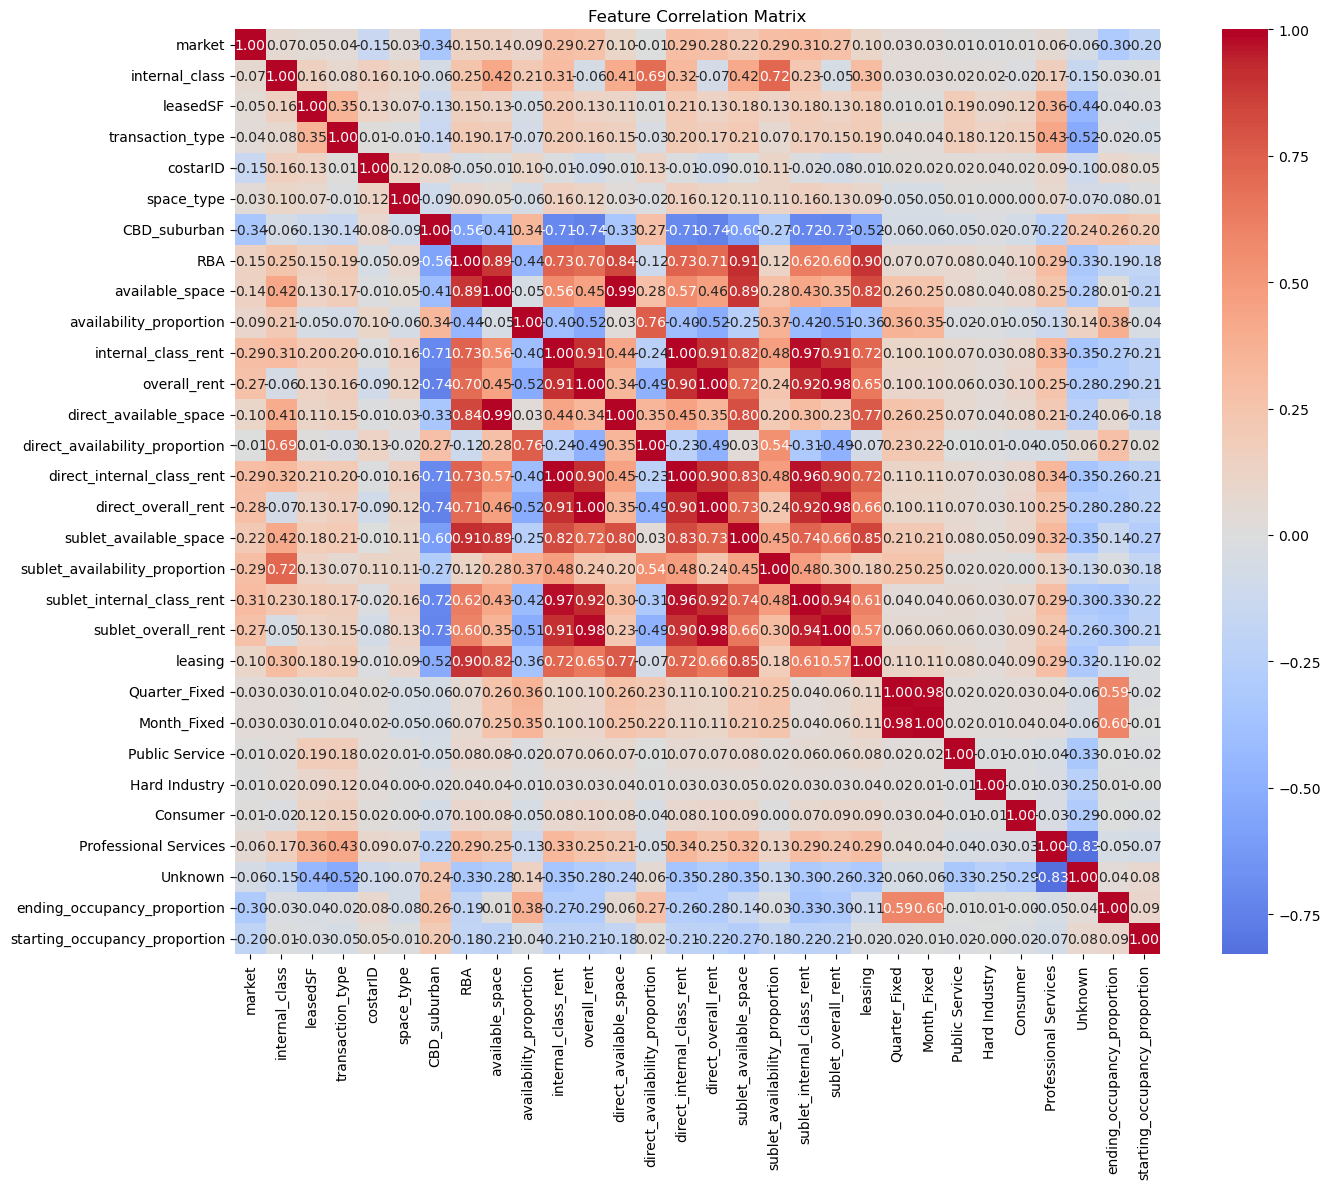


Highly correlated feature pairs (correlation > 0.8):
RBA -- available_space: 0.891
RBA -- direct_available_space: 0.837
RBA -- sublet_available_space: 0.915
RBA -- leasing: 0.896
available_space -- direct_available_space: 0.987
available_space -- sublet_available_space: 0.887
available_space -- leasing: 0.822
internal_class_rent -- overall_rent: 0.912
internal_class_rent -- direct_internal_class_rent: 0.999
internal_class_rent -- direct_overall_rent: 0.911
internal_class_rent -- sublet_available_space: 0.823
internal_class_rent -- sublet_internal_class_rent: 0.973
internal_class_rent -- sublet_overall_rent: 0.910
overall_rent -- direct_internal_class_rent: 0.904
overall_rent -- direct_overall_rent: 1.000
overall_rent -- sublet_internal_class_rent: 0.922
overall_rent -- sublet_overall_rent: 0.984
direct_available_space -- sublet_available_space: 0.803
direct_internal_class_rent -- direct_overall_rent: 0.903
direct_internal_class_rent -- sublet_available_space: 0.830
direct_internal_cla

In [61]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
import numpy as np

# Scale the features first
from sklearn.model_selection import train_test_split



# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values.argmax(axis=1), dtype=torch.long)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values.argmax(axis=1), dtype=torch.long)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values.argmax(axis=1), dtype=torch.long)

# Create DataLoaders
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


# Improved neural network architecture
class OccupancyNet(nn.Module):
    def __init__(self, input_size, num_classes):
        super(OccupancyNet, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_size, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.3),
            
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.2),
            
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.1),
            
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        return self.model(x)

# Initialize model
input_size = X_train.shape[1]
num_classes = len(torch.unique(y_train_tensor))
model = OccupancyNet(input_size, num_classes)

# Learning rate scheduler
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, verbose=True)
criterion = nn.CrossEntropyLoss()

# Training loop with early stopping
num_epochs = 50
best_loss = float('inf')
patience = 5
patience_counter = 0
best_model_state = None

for epoch in range(num_epochs):
    # Training phase
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # Gradient clipping
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total_train += y_batch.size(0)
        correct_train += (predicted == y_batch).sum().item()

    epoch_loss = running_loss/len(train_loader)
    train_accuracy = correct_train/total_train
    
    # Validation phase
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for X_batch, y_batch in val_loader:  # Changed from test_loader to val_loader
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += y_batch.size(0)
            correct += (predicted == y_batch).sum().item()
    
    val_loss = val_loss/len(test_loader)
    val_accuracy = correct/total
    
    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"Training Loss: {epoch_loss:.4f}, Training Accuracy: {train_accuracy:.4f}")
    print(f"Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.4f}")
    
    # Learning rate scheduling
    scheduler.step(val_loss)
    
    # Early stopping
    if val_loss < best_loss:
        best_loss = val_loss
        best_model_state = model.state_dict()
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping triggered")
            break

# Load best model
if best_model_state is not None:
    model.load_state_dict(best_model_state)

# Final evaluation
model.eval()
correct = 0
total = 0
predictions_list = []
actual_list = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = model(X_batch)
        _, predicted = torch.max(outputs, 1)
        total += y_batch.size(0)
        correct += (predicted == y_batch).sum().item()
        predictions_list.extend(predicted.numpy())
        actual_list.extend(y_batch.numpy())

final_accuracy = correct / total
print(f"\nFinal Test Accuracy: {final_accuracy:.4f}")

# Print confusion matrix
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(actual_list, predictions_list)
print("\nConfusion Matrix:")
sns.heatmap(cm, annot=True, fmt='d')
plt.show()

print("\nClassification Report:")
print(classification_report(actual_list, predictions_list))
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate correlation matrix
corr_matrix = X_train.corr()

# Create a larger figure for better readability
plt.figure(figsize=(15, 12))

# Create heatmap with correlation values
sns.heatmap(corr_matrix, 
            annot=True,  # Show correlation values
            cmap='coolwarm',  # Color scheme
            center=0,  # Center the colormap at 0
            fmt='.2f',  # Format correlation values to 2 decimal places
            square=True)  # Make the plot square-shaped

plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

# Print highly correlated feature pairs (above 0.8)
print("\nHighly correlated feature pairs (correlation > 0.8):")
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.8:
            print(f"{corr_matrix.columns[i]} -- {corr_matrix.columns[j]}: {corr_matrix.iloc[i, j]:.3f}")


/users/cdcook/.conda/envs/cobaya_2025/lib/python3.9/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1/50
Training Loss: 1.2723, Training Accuracy: 0.5134
Validation Loss: 0.6202, Validation Accuracy: 0.7514
Epoch 2/50
Training Loss: 0.6965, Training Accuracy: 0.7165
Validation Loss: 0.4332, Validation Accuracy: 0.8263
Epoch 3/50
Training Loss: 0.5477, Training Accuracy: 0.7801
Validation Loss: 0.3146, Validation Accuracy: 0.8736
Epoch 4/50
Training Loss: 0.4453, Training Accuracy: 0.8168
Validation Loss: 0.2402, Validation Accuracy: 0.8898
Epoch 5/50
Training Loss: 0.3767, Training Accuracy: 0.8480
Validation Loss: 0.2378, Validation Accuracy: 0.8983
Epoch 6/50
Training Loss: 0.3226, Training Accuracy: 0.8671
Validation Loss: 0.1719, Validation Accuracy: 0.9277
Epoch 7/50
Training Loss: 0.2797, Training Accuracy: 0.8844
Validation Loss: 0.1516, Validation Accuracy: 0.9211
Epoch 8/50
Training Loss: 0.2478, Training Accuracy: 0.9006
Validation Loss: 0.1164, Validation Accuracy: 0.9631
Epoch 9/50
Training Loss: 0.2360, Training Accuracy: 0.9076
Validation Loss: 0.1261, Validation 

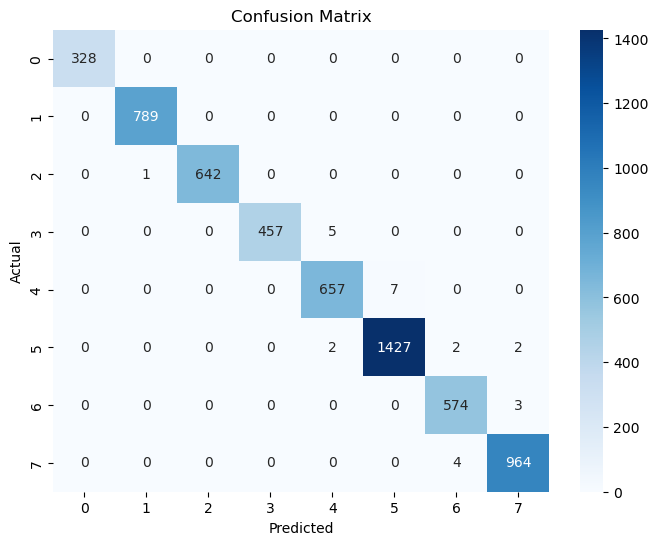

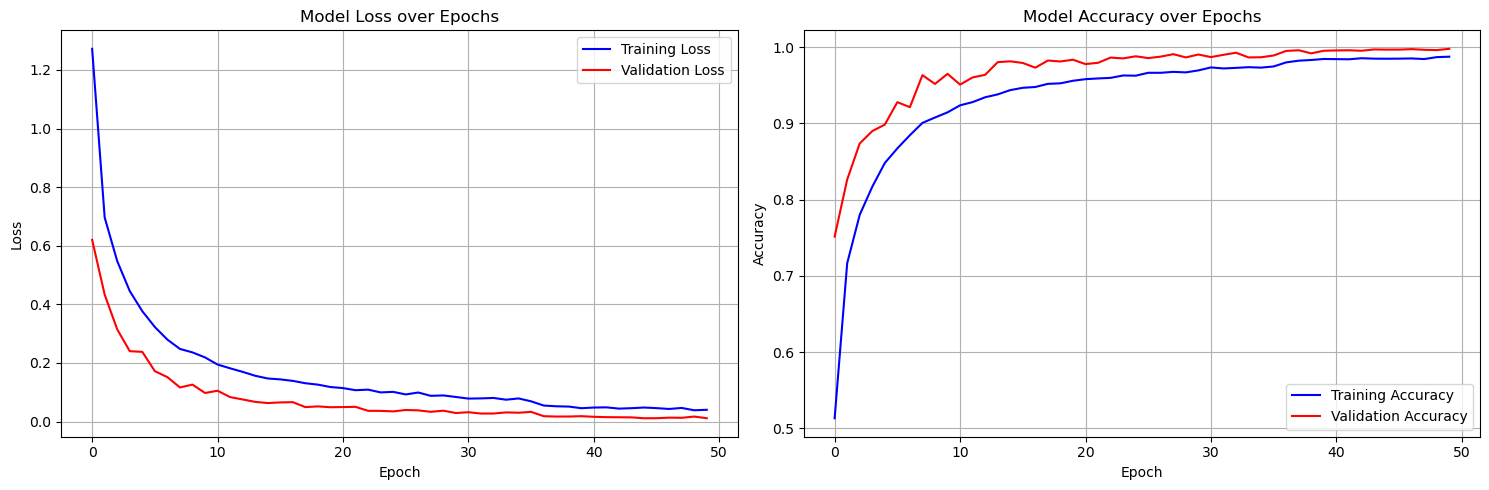


Final Training Loss: 0.0401
Final Validation Loss: 0.0114
Final Training Accuracy: 0.9873
Final Validation Accuracy: 0.9977


In [66]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
from torch.utils.data import DataLoader, TensorDataset

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []
# Standardize features
scaler = StandardScaler()
# Assuming prior scaling steps are correct
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Reshape for sequential input: (samples, timesteps, channels)
X_train_scaled = X_train_scaled.reshape(-1, 1, 30)  # Shape: (batch_size, 1, 30)
X_val_scaled = X_val_scaled.reshape(-1, 1, 30)      # Shape: (batch_size, 1, 30)
X_test_scaled = X_test_scaled.reshape(-1, 1, 30)    # Shape: (batch_size, 1, 30)

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values.argmax(axis=1), dtype=torch.long)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values.argmax(axis=1), dtype=torch.long)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values.argmax(axis=1), dtype=torch.long)

# Create DataLoaders
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
import torch.nn as nn
import torch.nn.functional as F

class AdaptedCNN(nn.Module):
    def __init__(self, input_channels=1, num_classes=8):
        super(AdaptedCNN, self).__init__()
        self.conv1 = nn.Conv1d(input_channels, 64, kernel_size=5, padding=2)  # Output: (batch, 64, 35)
        self.pool1 = nn.MaxPool1d(2)  # Output: (batch, 64, 17)
        self.dropout1 = nn.Dropout(0.3)
        
        self.conv2 = nn.Conv1d(64, 64, kernel_size=5, padding=2)  # Output: (batch, 64, 17)
        self.pool2 = nn.MaxPool1d(2)  # Output: (batch, 64, 8)
        self.dropout2 = nn.Dropout(0.2)
        
        self.conv3 = nn.Conv1d(64, 64, kernel_size=5, padding=2)  # Output: (batch, 64, 8)
        self.dropout3 = nn.Dropout(0.1)
        
        # Global average pooling and variance
        self.global_avg_pool = nn.AdaptiveAvgPool1d(1)  # Output: (batch, 64, 1)
        
        # Dense layers
        self.fc1 = nn.Linear(128, 64)  # 128 = 64 (mean) + 64 (variance)
        self.dropout4 = nn.Dropout(0.3)
        self.fc2 = nn.Linear(64, num_classes)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool1(x)
        x = self.dropout1(x)
        
        x = F.relu(self.conv2(x))
        x = self.pool2(x)
        x = self.dropout2(x)
        
        x = F.relu(self.conv3(x))
        x = self.dropout3(x)
        
        # Compute mean and variance
        mean = self.global_avg_pool(x).squeeze(-1)  # Shape: (batch, channels)
        variance = self.global_avg_pool((x - mean.unsqueeze(-1)) ** 2).squeeze(-1)  # Shape: (batch, channels)   # Compute variance manually
        
        # Concatenate features
        x = torch.cat([mean, variance], dim=1)  # (batch, 128)
        
        x = F.relu(self.fc1(x))
        x = self.dropout4(x)
        x = self.fc2(x)  # No activation (softmax in loss)
        return x

# Initialize model
model = AdaptedCNN(input_channels=1, num_classes=8)
import torch.optim as optim
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Training setup
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, verbose=True)
criterion = nn.CrossEntropyLoss()

# Training loop with early stopping
num_epochs = 50
best_loss = float('inf')
patience = 5
patience_counter = 0
best_model_state = None

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total_train += y_batch.size(0)
        correct_train += (predicted == y_batch).sum().item()

    epoch_loss = running_loss / len(train_loader)
    train_accuracy = correct_train / total_train
    
    # Validation
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += y_batch.size(0)
            correct += (predicted == y_batch).sum().item()
    
    val_loss = val_loss / len(val_loader)
    val_accuracy = correct / total
    train_losses.append(epoch_loss)
    train_accuracies.append(train_accuracy)
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"Training Loss: {epoch_loss:.4f}, Training Accuracy: {train_accuracy:.4f}")
    print(f"Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.4f}")
    
    scheduler.step(val_loss)
    
    if val_loss < best_loss:
        best_loss = val_loss
        best_model_state = model.state_dict()
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping triggered")
            break

# Load best model
model.load_state_dict(best_model_state)

# Final evaluation
model.eval()
predictions = []
actuals = []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = model(X_batch)
        _, predicted = torch.max(outputs, 1)
        predictions.extend(predicted.numpy())
        actuals.extend(y_batch.numpy())

print("\nClassification Report:")
print(classification_report(actuals, predictions))

cm = confusion_matrix(actuals, predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
plt.figure(figsize=(15, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss', color='blue')
plt.plot(val_losses, label='Validation Loss', color='red')
plt.title('Model Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Training Accuracy', color='blue')
plt.plot(val_accuracies, label='Validation Accuracy', color='red')
plt.title('Model Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Print final metrics
print(f"\nFinal Training Loss: {train_losses[-1]:.4f}")
print(f"Final Validation Loss: {val_losses[-1]:.4f}")
print(f"Final Training Accuracy: {train_accuracies[-1]:.4f}")
print(f"Final Validation Accuracy: {val_accuracies[-1]:.4f}")